# Sensitivity of drought-event detection to pooling gap and minimum duration

**Purpose.** Response analysis for **Reviewer #3, comment 1**, cross-referenced from **Reviewer #4, comment 4** (parameter sensitivity/adaptability).

**Reviewer's concern.** *"The study merges short non-drought interruptions of up to 10 days and excludes events shorter than 5 days. It is unclear how these parameters affect the number, duration, severity, or volumetric deficit of identified drought events, or whether they introduce bias across stations or sub-basins."*

**Context.** The manuscript's existing sensitivity analysis (Fig. 4, Fig. S1-S2, Table S1) covers the *propagation* parameters (search window W, minimum overlap M). It does not cover the *event-detection* parameters -- pooling gap and minimum duration -- which act at an earlier pipeline stage, directly on the daily SSI series. This notebook fills that gap.

**Inputs:** `data/SSI_daily.csv` (33 stations, daily SSI, 1961-2020), `data/caudales_diarios_imputados_CORE_FILTRADO.csv` (daily discharge, for volumetric severity).
**Outputs:** `sensitivity_summary.csv`, `sensitivity_per_station.csv`, `sensitivity_bias.csv`, `fig_detection_sensitivity.png/pdf`.

In [1]:
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
sys.path.insert(0, "..")  # shared modules live in revision_analyses/
from detection_sensitivity_core import (
    THRESHOLD, DEFAULT_POOL_GAP, DEFAULT_MIN_DURATION,
    add_doy, build_q_p10_lookup, run_detection, sensitivity_sweep,
)
DATA, OUT = "data/", "./"

## 1. Load data

In [2]:
df_ssi = pd.read_csv(DATA+"SSI_daily.csv", parse_dates=["date"])
Q_raw  = pd.read_csv(DATA+"caudales_diarios_imputados_CORE_FILTRADO.csv", parse_dates=["date"])
Q_raw  = add_doy(Q_raw[["station_id","date","Q_imp"]])
print(f"SSI: {len(df_ssi):,} rows, {df_ssi.station_id.nunique()} stations")
print(f"Q  : {len(Q_raw):,} rows, {Q_raw.station_id.nunique()} stations")
assert set(df_ssi.station_id.unique())==set(Q_raw.station_id.unique())

SSI: 723,195 rows, 33 stations
Q  : 723,195 rows, 33 stations


## 2. Build the P10 discharge lookup (once)
The climatological 10th-percentile discharge per station x day-of-year (+/-15-day circular window) is independent of the pooling/duration parameters being tested, so it is computed once and reused for every combination.

In [3]:
t0=time.time()
q_p10 = build_q_p10_lookup(Q_raw)
Q_lookup = Q_raw.merge(q_p10, on=["station_id","doy"], how="left").set_index("station_id")
print(f"Built in {time.time()-t0:.1f}s: {q_p10.shape}")

Built in 1.5s: (12078, 3)


## 3. Validate at the default configuration
Before running the sensitivity grid, we confirm that `run_detection()` at the published defaults (pooling = 10 d, minimum duration = 5 d) reproduces the manuscript's Table 3 statistics exactly.

In [4]:
ev_default = run_detection(df_ssi, Q_lookup, DEFAULT_POOL_GAP, DEFAULT_MIN_DURATION)
print(f"n_events: {len(ev_default)}  (paper: 2,625)")
print(f"duration  mean/median/max: {ev_default.duration.mean():.1f}/{ev_default.duration.median():.1f}/{ev_default.duration.max()}  (paper: 33.2/19.0/613)")
print(f"severity  mean/median/max: {ev_default.severity.mean():.3f}/{ev_default.severity.median():.3f}/{ev_default.severity.max():.3f}  (paper: 12.952/3.937/508.836)")
print(f"vol.sev.  mean/median/min/max: {ev_default.severity_hm3.mean():.3f}/{ev_default.severity_hm3.median():.3f}/{ev_default.severity_hm3.min():.3f}/{ev_default.severity_hm3.max():.3f}  (paper: 5.508/0.445/0.000/362.262)")
assert len(ev_default)==2625
print("Validated.")

n_events: 2625  (paper: 2,625)
duration  mean/median/max: 33.2/19.0/613  (paper: 33.2/19.0/613)
severity  mean/median/max: 12.952/3.937/508.836  (paper: 12.952/3.937/508.836)
vol.sev.  mean/median/min/max: 5.508/0.445/0.000/362.262  (paper: 5.508/0.445/0.000/362.262)
Validated.


## 4. Run the sensitivity grid
Pooling gap in {0, 5, 7, 10, 15} days x minimum duration in {3, 5, 7, 10} days (20 combinations; default = 10, 5). For each combination we compute (i) global summary statistics and (ii) a per-station bias/homogeneity check: the Spearman correlation, across the 33 stations, of event count and mean severity against the default configuration -- directly answering whether the parameter choice affects some stations more than others.

In [5]:
t0=time.time()
results = sensitivity_sweep(df_ssi, Q_lookup, pool_gaps=(0,5,7,10,15), min_durations=(3,5,7,10))
print(f"20 combinations in {time.time()-t0:.1f}s")
summary, per_station, bias = results["summary"], results["per_station"], results["bias"]
summary.to_csv(OUT+"sensitivity_summary.csv", index=False)
per_station.to_csv(OUT+"sensitivity_per_station.csv", index=False)
bias.to_csv(OUT+"sensitivity_bias.csv", index=False)
summary.round(3)

20 combinations in 55.1s


,pool_gap,min_duration,n_events,mean_duration,median_duration,mean_severity,median_severity,mean_intensity,median_intensity,mean_severity_hm3,median_severity_hm3,pct_change_n_events
0,0,3,5155,12.717,7.0,6.397,2.107,0.380,0.286,2.707,0.230,96.381
1,0,5,3661,16.514,10.0,8.643,3.543,0.428,0.338,3.608,0.343,39.467
2,0,7,2739,20.250,13.0,10.972,5.247,0.465,0.376,4.595,0.460,4.343
3,0,10,1977,25.001,18.0,14.041,7.714,0.498,0.415,5.933,0.642,-24.686
4,5,3,3700,21.408,12.0,9.225,2.585,0.312,0.225,3.915,0.309,40.952
5,5,5,3126,24.705,15.0,10.786,3.555,0.330,0.248,4.570,0.408,19.086
6,5,7,2671,27.987,17.0,12.409,4.730,0.347,0.267,5.263,0.519,1.752
7,5,10,2115,33.250,22.0,15.187,6.760,0.378,0.296,6.401,0.735,-19.429
8,7,3,3361,24.842,14.0,10.182,2.812,0.301,0.216,4.330,0.328,28.038
9,7,5,2885,28.371,16.0,11.742,3.730,0.317,0.234,4.986,0.433,9.905


## 5. Bias / homogeneity check

In [6]:
bias.round(3)

,pool_gap,min_duration,spearman_rho_n_events,spearman_p_n_events,spearman_rho_mean_severity,spearman_p_mean_severity
0,0,3,0.861,0.000,0.927,0.0
1,0,5,0.649,0.000,0.891,0.0
2,0,7,0.455,0.008,0.828,0.0
3,0,10,0.298,0.092,0.786,0.0
4,5,3,0.944,0.000,0.966,0.0
5,5,5,0.908,0.000,0.955,0.0
6,5,7,0.861,0.000,0.948,0.0
7,5,10,0.806,0.000,0.938,0.0
8,7,3,0.962,0.000,0.982,0.0
9,7,5,0.951,0.000,0.976,0.0


## 6. Publication figure

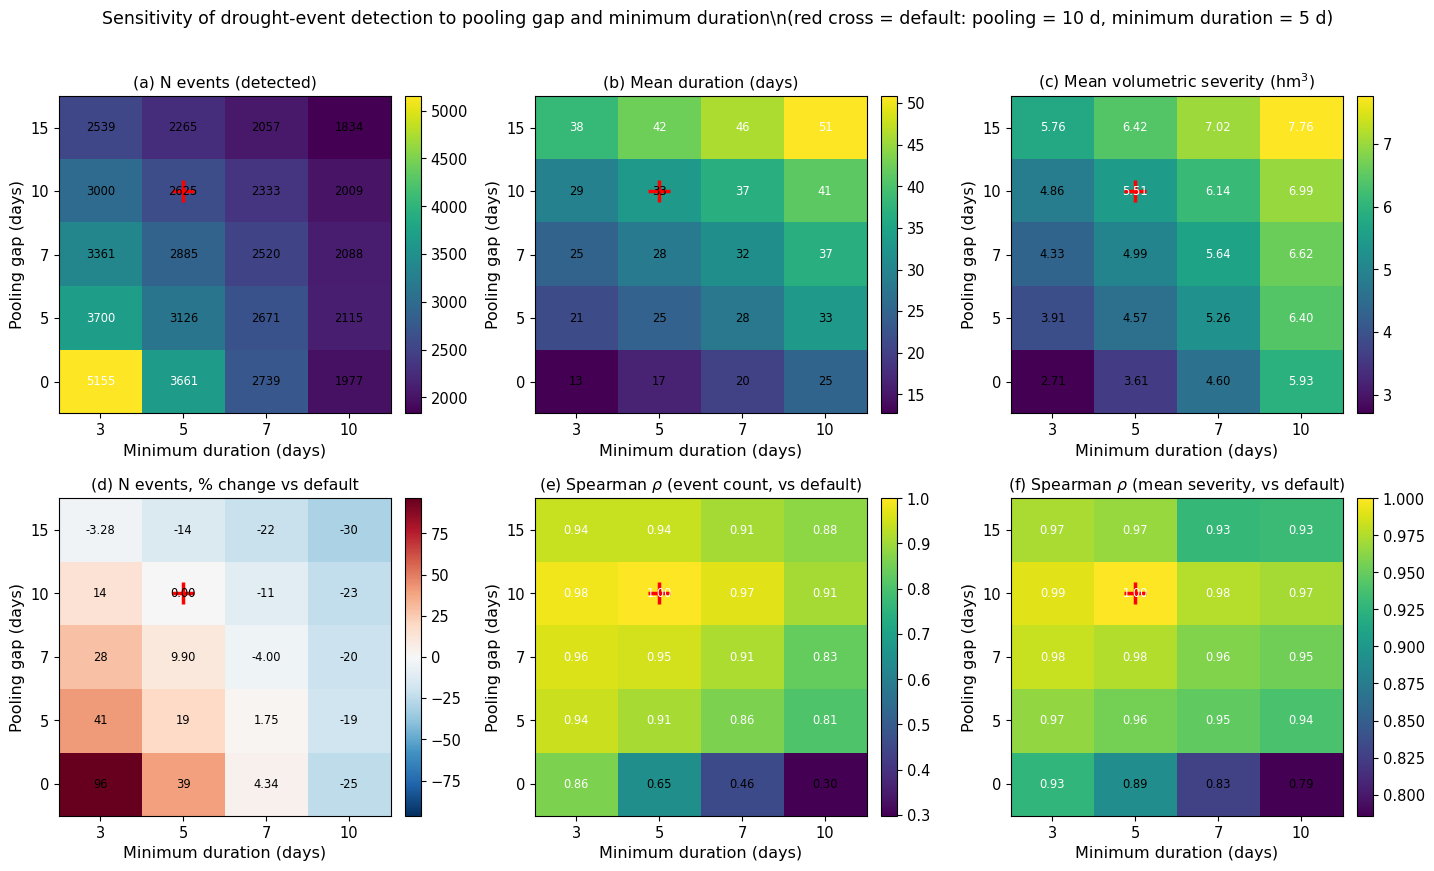

In [7]:
plt.rcParams.update({"font.size":11.5,"axes.titlesize":11.2,"axes.labelsize":11.5,
    "xtick.labelsize":10.5,"ytick.labelsize":10.5,"font.family":"DejaVu Sans"})
pool_gaps=sorted(summary.pool_gap.unique()); min_durations=sorted(summary.min_duration.unique())
def to_grid(df,col):
    g=df.pivot(index="pool_gap",columns="min_duration",values=col)
    return g.reindex(index=pool_gaps,columns=min_durations)
panels=[("n_events","N events (detected)",summary,"viridis"),
        ("mean_duration","Mean duration (days)",summary,"viridis"),
        ("mean_severity_hm3","Mean volumetric severity (hm$^3$)",summary,"viridis"),
        ("pct_change_n_events","N events, % change vs default",summary,"RdBu_r"),
        ("spearman_rho_n_events","Spearman $\\rho$ (event count, vs default)",bias,"viridis"),
        ("spearman_rho_mean_severity","Spearman $\\rho$ (mean severity, vs default)",bias,"viridis")]
fig,axes=plt.subplots(2,3,figsize=(14.5,8.6)); letters="abcdef"
for ax,(col,title,src,cmap),letter in zip(axes.flat,panels,letters):
    grid=to_grid(src,col); vals=grid.values.astype(float)
    if cmap=="RdBu_r":
        vmax=np.nanmax(np.abs(vals)); norm=mcolors.TwoSlopeNorm(vcenter=0,vmin=-vmax,vmax=vmax)
        im=ax.imshow(vals,cmap=cmap,norm=norm,aspect="auto",origin="lower")
    else:
        im=ax.imshow(vals,cmap=cmap,aspect="auto",origin="lower")
    ax.set_xticks(range(len(min_durations))); ax.set_xticklabels(min_durations)
    ax.set_yticks(range(len(pool_gaps))); ax.set_yticklabels(pool_gaps)
    ax.set_xlabel("Minimum duration (days)"); ax.set_ylabel("Pooling gap (days)")
    ax.set_title(f"({letter}) {title}",fontsize=11.3)
    for i in range(len(pool_gaps)):
        for j in range(len(min_durations)):
            v=vals[i,j]; txt=f"{v:.2f}" if abs(v)<10 else f"{v:.0f}"
            frac=(v-np.nanmin(vals))/(np.nanmax(vals)-np.nanmin(vals)+1e-9)
            color="white" if (cmap!="RdBu_r" and frac>0.55) else "black"
            ax.text(j,i,txt,ha="center",va="center",fontsize=8.3,color=color)
    di=pool_gaps.index(DEFAULT_POOL_GAP); dj=min_durations.index(DEFAULT_MIN_DURATION)
    ax.plot(dj,di,marker="+",color="red",markersize=16,markeredgewidth=2.5)
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
fig.suptitle("Sensitivity of drought-event detection to pooling gap and minimum duration\\n"
             "(red cross = default: pooling = 10 d, minimum duration = 5 d)",fontsize=12.5,y=1.01)
fig.tight_layout()
fig.savefig(OUT+"fig_detection_sensitivity.png",dpi=300,bbox_inches="tight")
fig.savefig(OUT+"fig_detection_sensitivity.pdf",bbox_inches="tight")
plt.show()

## 7. Interpretation

**Event counts and characteristics are genuinely sensitive to both parameters** (unlike the propagation parameters W and M, which showed RSI = 0 / near-zero sensitivity). Event count ranges from -30% to +96% relative to the default across the tested grid; mean duration, severity and volumetric severity all increase substantially with more pooling and higher minimum-duration thresholds, and decrease with less pooling / lower thresholds. This is expected and well documented in the drought literature (e.g. Fleig et al., 2006): pooling and duration thresholds are definitional choices in any threshold-level drought identification method, and they mechanically trade off event count against event length -- more pooling merges more short interruptions into fewer, longer episodes; a higher minimum duration discards more short events.

**Bias / homogeneity across stations.** The relevant question is not whether raw counts change (they must, by construction) but whether the *relative ranking* of stations is preserved -- i.e. whether some stations are disproportionately gaining or losing events as parameters change. Mean-severity ranking across stations is remarkably stable across the whole tested grid (Spearman rho typically 0.83-1.00, only dropping to 0.79 at the most extreme configuration). Event-count ranking is also stable across most of the grid (rho > 0.8) but degrades more noticeably at zero pooling with strict duration filtering (rho as low as 0.30 at pooling=0, min_duration=10), indicating that removing pooling altogether does introduce some station-specific distortion in raw event counts -- plausibly because short, frequent low-flow interruptions are more common at some stations (e.g. flashier headwater regimes) than others.

**Conclusion.** The published configuration (pooling = 10 d, minimum duration = 5 d) sits within literature-recommended ranges (Van Loon, 2015; Fleig et al., 2006) and is not at an unstable extreme of the tested grid: at this configuration, and across most of the tested range, station rankings by severity and event count are well preserved, supporting the choice as a reasonable, non-arbitrary and non-biasing one, while acknowledging -- as is inherent to any threshold-based method -- that the exact event catalogue (and hence downstream propagation-chain counts) is sensitive to these definitional choices.